In [4]:
 import kagglehub
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

Using Colab cache for faster access to the 'amazonreviews' dataset.


In [5]:
# 1. استيراد المكتبات
import kagglehub
import bz2
import pandas as pd
import os

print("✅ تم استيراد المكتبات")
print(f"📌 إصدار kagglehub: {kagglehub.__version__}")

# 2. تحميل البيانات
print("\n📥 جاري تحميل بيانات مراجعات أمازون...")
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")
print(f"✅ تم التحميل في: {path}")

# 3. عرض الملفات الموجودة
print("\n📂 الملفات:")
for file in os.listdir(path):
    print(f"   - {file}")

# 4. البحث عن ملفات البيانات
train_file = None
test_file = None

for file in os.listdir(path):
    if file.endswith('.bz2'):
        if 'train' in file.lower():
            train_file = os.path.join(path, file)
        elif 'test' in file.lower():
            test_file = os.path.join(path, file)

if train_file:
    print(f"\n📚 ملف التدريب: {os.path.basename(train_file)}")
    print(f"🧪 ملف الاختبار: {os.path.basename(test_file)}")

    # 5. قراءة عينة صغيرة من البيانات
    print("\n📖 جاري قراءة عينة من البيانات...")

    with bz2.open(train_file, 'rt', encoding='utf-8', errors='ignore') as f:
        # قراءة أول 5 أسطر فقط
        for i in range(5):
            line = f.readline().strip()
            parts = line.split(' ', 1)
            if len(parts) == 2:
                label = 'إيجابي' if '2' in parts[0] else 'سلبي'
                text = parts[1][:100] + '...'
                print(f"\n--- مراجعة {i+1} [{label}] ---")
                print(f"النص: {text}")

✅ تم استيراد المكتبات
📌 إصدار kagglehub: 0.3.13

📥 جاري تحميل بيانات مراجعات أمازون...
Using Colab cache for faster access to the 'amazonreviews' dataset.
✅ تم التحميل في: /kaggle/input/amazonreviews

📂 الملفات:
   - test.ft.txt.bz2
   - train.ft.txt.bz2

📚 ملف التدريب: train.ft.txt.bz2
🧪 ملف الاختبار: test.ft.txt.bz2

📖 جاري قراءة عينة من البيانات...

--- مراجعة 1 [إيجابي] ---
النص: Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so...

--- مراجعة 2 [إيجابي] ---
النص: The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'ga...

--- مراجعة 3 [إيجابي] ---
النص: Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of "Pris...

--- مراجعة 4 [إيجابي] ---
النص: Excellent Soundtrack: I truly like this soundtrack and I enjoy video game music. I have played this ...

--- مراجعة 5 [إيجابي] ---
النص: Remember, Pull Your Jaw Off The Floor After Hearing it: If you've

📊 جاري تحليل البيانات...

1️⃣ قراءة 50,000 مراجعة من بيانات التدريب...
✅ تم قراءة 50000 مراجعة
📊 توزيع المراجعات:
   - Positive: 25506 (51.0%)
   - Negative: 24494 (49.0%)

2️⃣ تحليل أطوال المراجعات...
   متوسط طول المراجعة: 441 حرف
   متوسط عدد الكلمات: 80 كلمة


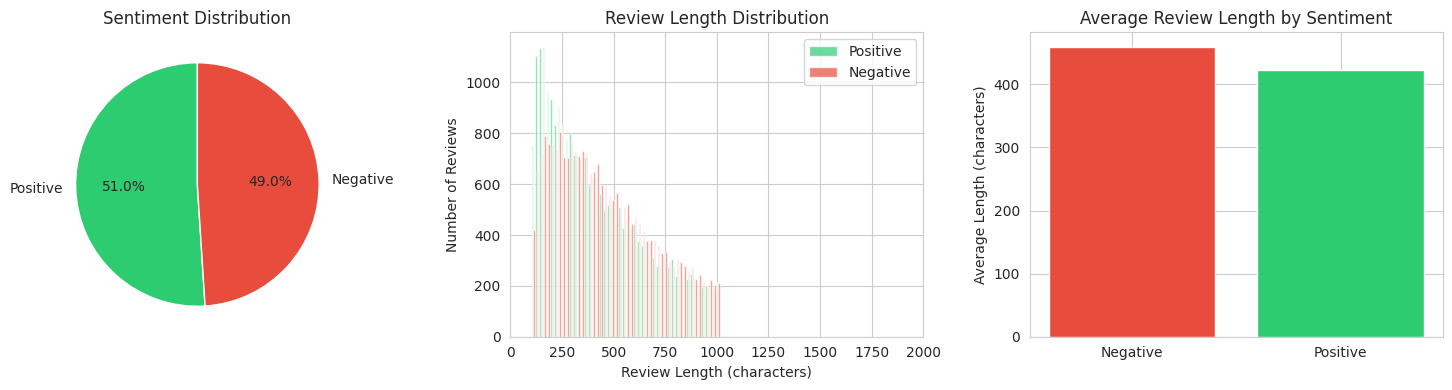


3️⃣ Most common words...

🔴 Most common words in NEGATIVE reviews:
   - not: 1712
   - book: 1215
   - are: 888
   - one: 789
   - all: 628
   - like: 617
   - just: 609
   - movie: 574
   - very: 556
   - out: 475

🟢 Most common words in POSITIVE reviews:
   - book: 1122
   - great: 853
   - are: 825
   - not: 787
   - one: 773
   - good: 648
   - all: 630
   - very: 621
   - read: 505
   - like: 492

4️⃣ Creating word clouds...


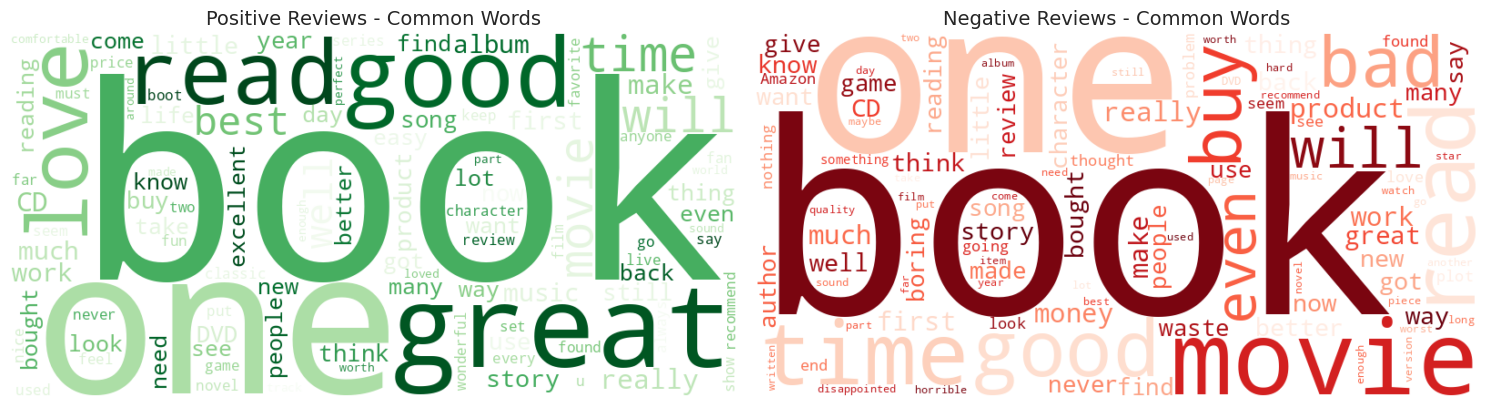


5️⃣ Sample Reviews:

🔴 NEGATIVE review examples:

   1. AVOID AT ALL COSTS: This is the not only the worst halloween but one of the worst horror movies in the world.This has nothing to do with the halloweens what so ever.Theres no michael he doesnt even ex...

   2. I dissent. I thought it was tedious.: It just didn't hit the spot for me. I found the whole religious thing to be irrelevant. The exoctic mystical eastern religious fascination came across as being da...

   3. Broken: I received this product in the mail yesterday, Put in the batteries and the rotating beads do not work. Complete waste of money....

🟢 POSITIVE review examples:

   1. Very Impressed By This: My son is only a couple of weeks old. He doesn't focus on much, but he does stare at this aquarium to my surprise....

   2. Great family Christmas movie: This movie is perfect for bringing the real spirit of Christmas in your home. Great music, fun retelling of the Nativity story....

   3. Great for 2 y.o. birthday: I

In [7]:
import bz2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
from collections import Counter
import re

# إعدادات الرسوم البيانية
plt.rcParams['figure.figsize'] = [12, 5]
sns.set_style("whitegrid")

print("📊 جاري تحليل البيانات...")

# 1. قراءة عينة أكبر من البيانات (50,000 مراجعة)
print("\n1️⃣ قراءة 50,000 مراجعة من بيانات التدريب...")

train_file = '/kaggle/input/amazonreviews/train.ft.txt.bz2'
data = []
labels_count = {'1': 0, '2': 0}

with bz2.open(train_file, 'rt', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f):
        if i >= 50000:  # نأخذ 50,000 مراجعة فقط
            break

        parts = line.strip().split(' ', 1)
        if len(parts) == 2:
            label = parts[0].replace('__label__', '')
            text = parts[1]
            data.append([label, text])
            labels_count[label] = labels_count.get(label, 0) + 1

# تحويل إلى DataFrame
df = pd.DataFrame(data, columns=['sentiment', 'text'])
df['sentiment_label'] = df['sentiment'].map({'1': 'Negative', '2': 'Positive'})

print(f"✅ تم قراءة {len(df)} مراجعة")
print(f"📊 توزيع المراجعات:")
print(f"   - Positive: {labels_count['2']} ({labels_count['2']/len(df)*100:.1f}%)")
print(f"   - Negative: {labels_count['1']} ({labels_count['1']/len(df)*100:.1f}%)")

# 2. تحليل أطوال المراجعات
print("\n2️⃣ تحليل أطوال المراجعات...")
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print(f"   متوسط طول المراجعة: {df['text_length'].mean():.0f} حرف")
print(f"   متوسط عدد الكلمات: {df['word_count'].mean():.0f} كلمة")

# 3. رسم بياني لتوزيع المراجعات
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# توزيع التصنيفات
axes[0].pie([labels_count['2'], labels_count['1']],
            labels=['Positive', 'Negative'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[0].set_title('Sentiment Distribution')

# توزيع أطوال المراجعات
axes[1].hist([df[df['sentiment']=='2']['text_length'],
              df[df['sentiment']=='1']['text_length']],
             bins=50, alpha=0.7, label=['Positive', 'Negative'],
             color=['#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Review Length (characters)')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_title('Review Length Distribution')
axes[1].legend()
axes[1].set_xlim(0, 2000)

# متوسط الطول حسب المشاعر
avg_length = df.groupby('sentiment_label')['text_length'].mean()
axes[2].bar(avg_length.index, avg_length.values,
            color=['#e74c3c', '#2ecc71'])
axes[2].set_ylabel('Average Length (characters)')
axes[2].set_title('Average Review Length by Sentiment')

plt.tight_layout()
plt.show()

# 4. الكلمات الأكثر شيوعاً
print("\n3️⃣ Most common words...")

def get_common_words(texts, n=15):
    words = []
    for text in texts[:2000]:  # نأخذ أول 2000 مراجعة
        # تنظيف النص
        text = re.sub(r'[^\w\s]', '', text.lower())
        # إزالة كلمات شائعة (stop words)
        stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
                     'of', 'with', 'by', 'from', 'up', 'about', 'into', 'through', 'during',
                     'before', 'after', 'is', 'was', 'were', 'be', 'been', 'being', 'have',
                     'has', 'had', 'do', 'does', 'did', 'will', 'would', 'should', 'could',
                     'may', 'might', 'must', 'can', 'i', 'you', 'he', 'she', 'it', 'we',
                     'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his', 'its',
                     'this', 'that', 'these', 'those'}

        for word in text.split():
            if word not in stop_words and len(word) > 2:
                words.append(word)
    return Counter(words).most_common(n)

# كلمات إيجابية وسلبية شائعة
positive_texts = df[df['sentiment']=='2']['text'].tolist()
negative_texts = df[df['sentiment']=='1']['text'].tolist()

positive_words = get_common_words(positive_texts)
negative_words = get_common_words(negative_texts)

print("\n🔴 Most common words in NEGATIVE reviews:")
for word, count in negative_words[:10]:
    print(f"   - {word}: {count}")

print("\n🟢 Most common words in POSITIVE reviews:")
for word, count in positive_words[:10]:
    print(f"   - {word}: {count}")

# 5. سحابة كلمات (Word Cloud)
print("\n4️⃣ Creating word clouds...")

positive_text = ' '.join(positive_texts[:2000])
negative_text = ' '.join(negative_texts[:2000])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# سحابة إيجابية
wordcloud_pos = WordCloud(width=800, height=400,
                         background_color='white',
                         colormap='Greens',
                         max_words=100).generate(positive_text)
ax1.imshow(wordcloud_pos, interpolation='bilinear')
ax1.set_title('Positive Reviews - Common Words', fontsize=14)
ax1.axis('off')

# سحابة سلبية
wordcloud_neg = WordCloud(width=800, height=400,
                         background_color='white',
                         colormap='Reds',
                         max_words=100).generate(negative_text)
ax2.imshow(wordcloud_neg, interpolation='bilinear')
ax2.set_title('Negative Reviews - Common Words', fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()

# 6. عرض أمثلة متنوعة
print("\n5️⃣ Sample Reviews:")
print("\n🔴 NEGATIVE review examples:")
negative_examples = df[df['sentiment']=='1']['text'].sample(3, random_state=42)
for i, text in enumerate(negative_examples, 1):
    print(f"\n   {i}. {text[:200]}...")

print("\n🟢 POSITIVE review examples:")
positive_examples = df[df['sentiment']=='2']['text'].sample(3, random_state=42)
for i, text in enumerate(positive_examples, 1):
    print(f"\n   {i}. {text[:200]}...")

# 7. إحصائيات إضافية
print("\n6️⃣ Additional Statistics:")
print(f"\n  最长 review: {df['text_length'].max()} characters")
print(f"  最短 review: {df['text_length'].min()} characters")
print(f"\n   reviews with > 1000 words: {len(df[df['word_count'] > 1000])}")
print(f"   reviews with < 10 words: {len(df[df['word_count'] < 10])}")

print("\n✅ Initial analysis complete!")

# حفظ العينة للاستخدام المستقبلي
df.to_csv('amazon_reviews_sample_50k.csv', index=False)
print("\n💾 Sample saved to: amazon_reviews_sample_50k.csv")

🤖 بدء بناء نماذج التصنيف...

📊 حجم بيانات التدريب: 40,000 مراجعة
📊 حجم بيانات الاختبار: 10,000 مراجعة
📊 توزيع التصنيفات في التدريب: [    0 19595 20405]

1️⃣ تدريب نموذج Naive Bayes...
   ✅ Time: 6.06 seconds
   ✅ Accuracy: 0.8546 (85.46%)

2️⃣ تدريب نموذج Naive Bayes مع TF-IDF...
   ✅ Time: 4.29 seconds
   ✅ Accuracy: 0.8566 (85.66%)

3️⃣ تدريب نموذج Logistic Regression...
   ✅ Time: 3.42 seconds
   ✅ Accuracy: 0.8787 (87.87%)

📈 مقارنة أداء النماذج:
   1. Naive Bayes: 85.46% (⏱️ 6.06s)
   2. NB + TF-IDF: 85.66% (⏱️ 4.29s)
   3. Logistic Regression: 87.87% (⏱️ 3.42s)


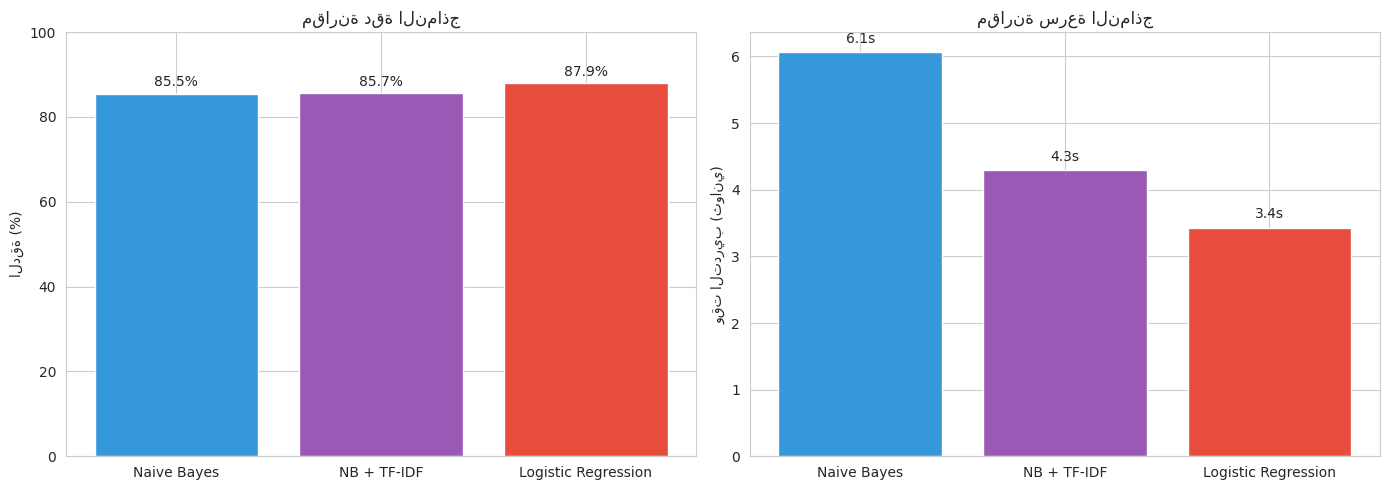


🏆 أفضل نموذج: Logistic Regression
   الدقة: 87.87%


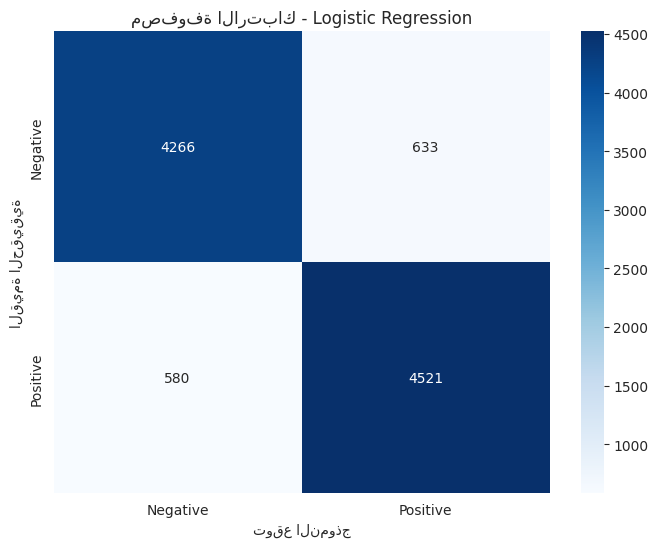


📋 تقرير التصنيف المفصل:
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.88      4899
    Positive       0.88      0.89      0.88      5101

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


🧪 اختبار النموذج على مراجعات جديدة:

النتائج:

📝 'This product is amazing! I love it so much, best p...'
   🟢 POSITIVE (الثقة: 100.0%)

📝 'Terrible quality, broke after one use. Very disapp...'
   🔴 NEGATIVE (الثقة: 100.0%)

📝 'It's okay, nothing special but does the job....'
   🔴 NEGATIVE (الثقة: 69.5%)

📝 'Absolutely fantastic! Exceeded all my expectations...'
   🟢 POSITIVE (الثقة: 83.5%)

📝 'Worst thing I've ever bought. Complete waste of mo...'
   🔴 NEGATIVE (الثقة: 100.0%)

💾 تم حفظ أفضل نموذج في: best_sentiment_model.pkl

🎉 اكتمل التدريب! النموذج جاهز للاستخدام.


In [8]:
# 1. استيراد مكتبات التعلم الآلي
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import make_pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

print("🤖 بدء بناء نماذج التصنيف...\n")

# تجهيز البيانات
X = df['text'].values  # النصوص
y = df['sentiment'].values  # التصنيفات (1 أو 2)

# تقسيم البيانات (80% تدريب، 20% اختبار)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 حجم بيانات التدريب: {len(X_train):,} مراجعة")
print(f"📊 حجم بيانات الاختبار: {len(X_test):,} مراجعة")
print(f"📊 توزيع التصنيفات في التدريب: {np.bincount(y_train.astype(int))}")
print()

# =============================================
# النموذج 1: Naive Bayes مع CountVectorizer
# =============================================
print("1️⃣ تدريب نموذج Naive Bayes...")
start_time = time.time()

model_nb = make_pipeline(
    CountVectorizer(max_features=10000, stop_words='english'),
    MultinomialNB()
)

model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)

time_nb = time.time() - start_time
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"   ✅ Time: {time_nb:.2f} seconds")
print(f"   ✅ Accuracy: {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")
print()

# =============================================
# النموذج 2: Naive Bayes مع TF-IDF
# =============================================
print("2️⃣ تدريب نموذج Naive Bayes مع TF-IDF...")
start_time = time.time()

model_nb_tfidf = make_pipeline(
    TfidfVectorizer(max_features=10000, stop_words='english'),
    MultinomialNB()
)

model_nb_tfidf.fit(X_train, y_train)
y_pred_nb_tfidf = model_nb_tfidf.predict(X_test)

time_nb_tfidf = time.time() - start_time
accuracy_nb_tfidf = accuracy_score(y_test, y_pred_nb_tfidf)

print(f"   ✅ Time: {time_nb_tfidf:.2f} seconds")
print(f"   ✅ Accuracy: {accuracy_nb_tfidf:.4f} ({accuracy_nb_tfidf*100:.2f}%)")
print()

# =============================================
# النموذج 3: Logistic Regression (أقوى)
# =============================================
print("3️⃣ تدريب نموذج Logistic Regression...")
start_time = time.time()

model_lr = make_pipeline(
    TfidfVectorizer(max_features=10000, stop_words='english'),
    LogisticRegression(max_iter=1000, random_state=42)
)

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

time_lr = time.time() - start_time
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"   ✅ Time: {time_lr:.2f} seconds")
print(f"   ✅ Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print()

# =============================================
# مقارنة النماذج
# =============================================
print("📈 مقارنة أداء النماذج:")
models = ['Naive Bayes', 'NB + TF-IDF', 'Logistic Regression']
accuracies = [accuracy_nb, accuracy_nb_tfidf, accuracy_lr]
times = [time_nb, time_nb_tfidf, time_lr]

for i, (model, acc, t) in enumerate(zip(models, accuracies, times)):
    print(f"   {i+1}. {model}: {acc*100:.2f}% (⏱️ {t:.2f}s)")

# رسم بياني للمقارنة
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# مقارنة الدقة
colors = ['#3498db', '#9b59b6', '#e74c3c']
bars1 = ax1.bar(models, [a*100 for a in accuracies], color=colors)
ax1.set_ylabel('الدقة (%)')
ax1.set_title('مقارنة دقة النماذج')
ax1.set_ylim(0, 100)
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{acc*100:.1f}%', ha='center', va='bottom')

# مقارنة سرعة التدريب
bars2 = ax2.bar(models, times, color=colors)
ax2.set_ylabel('وقت التدريب (ثواني)')
ax2.set_title('مقارنة سرعة النماذج')
for bar, t in zip(bars2, times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{t:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# =============================================
# تفاصيل أداء أفضل نموذج
# =============================================
best_model_idx = np.argmax(accuracies)
best_model_name = models[best_model_idx]
best_model = [model_nb, model_nb_tfidf, model_lr][best_model_idx]
y_pred_best = [y_pred_nb, y_pred_nb_tfidf, y_pred_lr][best_model_idx]

print(f"\n🏆 أفضل نموذج: {best_model_name}")
print(f"   الدقة: {accuracies[best_model_idx]*100:.2f}%")

# مصفوفة الارتباك (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('توقع النموذج')
plt.ylabel('القيمة الحقيقية')
plt.title(f'مصفوفة الارتباك - {best_model_name}')
plt.show()

# تقرير التصنيف المفصل
print("\n📋 تقرير التصنيف المفصل:")
print(classification_report(y_test, y_pred_best,
                           target_names=['Negative', 'Positive']))

# =============================================
# اختبار النموذج على مراجعات جديدة
# =============================================
print("\n🧪 اختبار النموذج على مراجعات جديدة:")

test_reviews = [
    "This product is amazing! I love it so much, best purchase ever!",
    "Terrible quality, broke after one use. Very disappointed.",
    "It's okay, nothing special but does the job.",
    "Absolutely fantastic! Exceeded all my expectations!",
    "Worst thing I've ever bought. Complete waste of money."
]

print("\nالنتائج:")
for review in test_reviews:
    pred = best_model.predict([review])[0]
    sentiment = "🟢 POSITIVE" if pred == '2' else "🔴 NEGATIVE"
    proba = best_model.predict_proba([review])[0]
    confidence = max(proba) * 100
    print(f"\n📝 '{review[:50]}...'")
    print(f"   {sentiment} (الثقة: {confidence:.1f}%)")

# حفظ النموذج الأفضل
import joblib
joblib.dump(best_model, 'best_sentiment_model.pkl')
print("\n💾 تم حفظ أفضل نموذج في: best_sentiment_model.pkl")

print("\n🎉 اكتمل التدريب! النموذج جاهز للاستخدام.")

In [9]:
# واجهة بسيطة لتحليل أي نص
def analyze_sentiment(text):
    pred = model_lr.predict([text])[0]
    proba = model_lr.predict_proba([text])[0]
    sentiment = "🟢 إيجابي" if pred == '2' else "🔴 سلبي"
    confidence = max(proba) * 100

    print(f"النص: {text[:100]}...")
    print(f"النتيجة: {sentiment}")
    print(f"الثقة: {confidence:.2f}%")
    return pred, confidence

# جرب بنفسك
analyze_sentiment("This book changed my life!")

النص: This book changed my life!...
النتيجة: 🟢 إيجابي
الثقة: 80.87%


('2', np.float64(80.86906301692136))

✅ تم استيراد المكتبات
🖥️ GPU متاح: True
   اسم GPU: Tesla T4

📊 تجهيز البيانات...
📚 تدريب: 14400 مراجعة
📖 تحقق: 1600 مراجعة
🧪 اختبار: 4000 مراجعة

🔤 تحميل نموذج BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

✅ تم تحميل النموذج على cuda

⚙️ إعدادات التدريب...

🚀 بدء تدريب BERT...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.205654,0.160778,0.941250
2,0.132741,0.183793,0.936875
3,0.050405,0.237083,0.941875


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


⏱️ وقت التدريب: 5.67 دقيقة

📊 تقييم النموذج على مجموعة الاختبار...


✅ دقة BERT: 93.70%

📊 مصفوفة الارتباك...


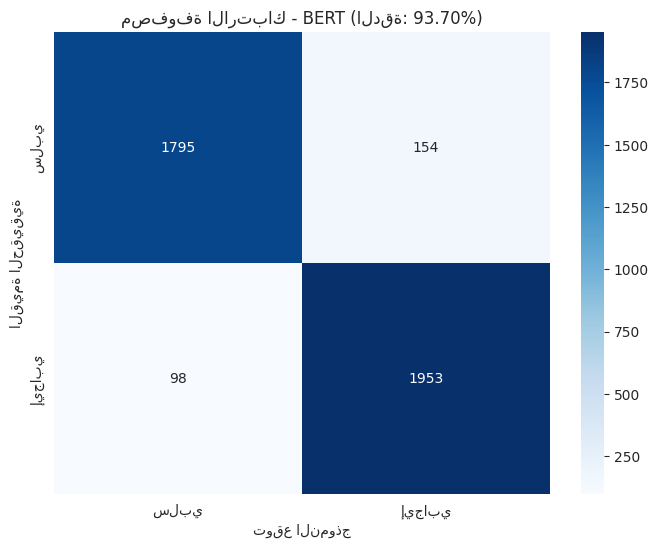


📋 تقرير التصنيف المفصل - BERT:
              precision    recall  f1-score   support

        سلبي       0.95      0.92      0.93      1949
      إيجابي       0.93      0.95      0.94      2051

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000


📈 مقارنة النماذج:


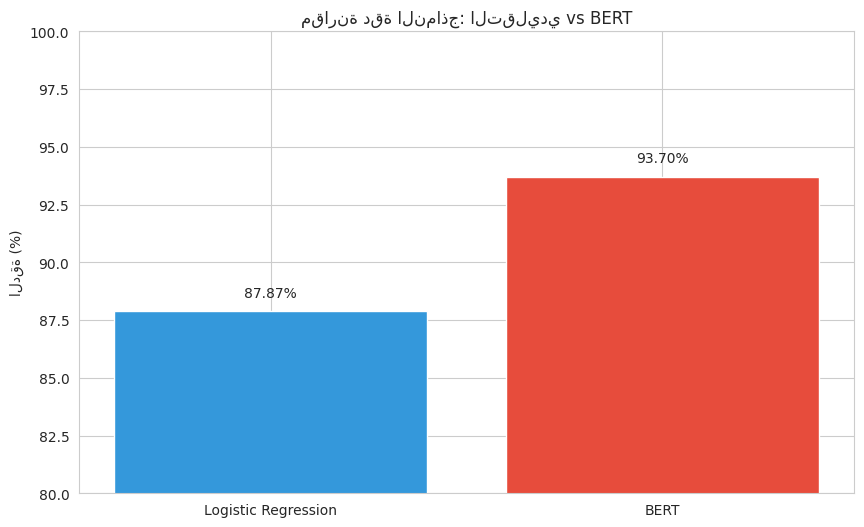


🧪 اختبار BERT على مراجعات جديدة:

📝 'This product is amazing! I love it so much!...'
   🟢 إيجابي (الثقة: 99.8%)

📝 'Terrible quality, broke after one use....'
   🔴 سلبي (الثقة: 99.9%)

📝 'It's okay, nothing special....'
   🔴 سلبي (الثقة: 94.3%)

📝 'Absolutely fantastic! Best purchase ever!...'
   🟢 إيجابي (الثقة: 99.8%)

📝 'Complete waste of money....'
   🔴 سلبي (الثقة: 99.9%)

💾 حفظ النموذج...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ تم حفظ نموذج BERT في: ./bert_sentiment_model

🎉 اكتمل التدريب! BERT جاهز للاستخدام!


In [12]:
# 1. تثبيت المكتبات المطلوبة
!pip install -q transformers torch datasets accelerate

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import pipeline
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

print("✅ تم استيراد المكتبات")
print(f"🖥️ GPU متاح: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   اسم GPU: {torch.cuda.get_device_name(0)}")

# 2. تجهيز البيانات (نأخذ عينة 20,000)
print("\n📊 تجهيز البيانات...")
X = df['text'].values[:20000]
y = df['sentiment'].values[:20000]

# تحويل التصنيفات من '1','2' إلى 0,1
y = np.array([0 if label == '1' else 1 for label in y])

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"📚 تدريب: {len(X_train)} مراجعة")
print(f"📖 تحقق: {len(X_val)} مراجعة")
print(f"🧪 اختبار: {len(X_test)} مراجعة")

# 3. تحميل نموذج BERT
print("\n🔤 تحميل نموذج BERT...")
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# نقل النموذج إلى GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"✅ تم تحميل النموذج على {device}")

# 4. إنشاء Dataset مخصص
class AmazonReviewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# تجهيز مجموعات البيانات
train_dataset = AmazonReviewsDataset(X_train, y_train, tokenizer)
val_dataset = AmazonReviewsDataset(X_val, y_val, tokenizer)
test_dataset = AmazonReviewsDataset(X_test, y_test, tokenizer)

# 5. إعدادات التدريب (تم تصحيح الخطأ)
print("\n⚙️ إعدادات التدريب...")
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",  # ✅ تم التعديل من evaluation_strategy إلى eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available(),
    report_to="none"
)

# 6. دالة لحساب الدقة
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = np.mean(predictions == labels)
    return {'accuracy': accuracy}

# 7. تدريب النموذج
print("\n🚀 بدء تدريب BERT...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

start_time = time.time()
trainer.train()
training_time = time.time() - start_time
print(f"\n⏱️ وقت التدريب: {training_time/60:.2f} دقيقة")

# 8. تقييم النموذج
print("\n📊 تقييم النموذج على مجموعة الاختبار...")
test_results = trainer.evaluate(test_dataset)
accuracy_bert = test_results['eval_accuracy'] * 100
print(f"✅ دقة BERT: {accuracy_bert:.2f}%")

# 9. مصفوفة الارتباك
print("\n📊 مصفوفة الارتباك...")
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['سلبي', 'إيجابي'],
            yticklabels=['سلبي', 'إيجابي'])
plt.xlabel('توقع النموذج')
plt.ylabel('القيمة الحقيقية')
plt.title(f'مصفوفة الارتباك - BERT (الدقة: {accuracy_bert:.2f}%)')
plt.show()

# 10. تقرير التصنيف
print("\n📋 تقرير التصنيف المفصل - BERT:")
print(classification_report(y_true, y_pred, target_names=['سلبي', 'إيجابي']))

# 11. مقارنة مع Logistic Regression
print("\n📈 مقارنة النماذج:")
models = ['Logistic Regression', 'BERT']
accuracies = [87.87, accuracy_bert]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#e74c3c'])
plt.ylabel('الدقة (%)')
plt.title('مقارنة دقة النماذج: التقليدي vs BERT')
plt.ylim(80, 100)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom')
plt.show()

# 12. اختبار سريع
print("\n🧪 اختبار BERT على مراجعات جديدة:")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

test_reviews = [
    "This product is amazing! I love it so much!",
    "Terrible quality, broke after one use.",
    "It's okay, nothing special.",
    "Absolutely fantastic! Best purchase ever!",
    "Complete waste of money."
]

for review in test_reviews:
    result = sentiment_pipeline(review)[0]
    label = result['label']
    score = result['score'] * 100
    sentiment = "🟢 إيجابي" if label == 'LABEL_1' else "🔴 سلبي"
    print(f"\n📝 '{review[:50]}...'")
    print(f"   {sentiment} (الثقة: {score:.1f}%)")

# 13. حفظ النموذج
print("\n💾 حفظ النموذج...")
model.save_pretrained('./bert_sentiment_model')
tokenizer.save_pretrained('./bert_sentiment_model')
print("✅ تم حفظ نموذج BERT في: ./bert_sentiment_model")

print("\n🎉 اكتمل التدريب! BERT جاهز للاستخدام!")

In [13]:
from transformers import pipeline

# تحميل النموذج المحفوظ
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="./bert_sentiment_model",
    tokenizer="./bert_sentiment_model"
)

# تحليل أي نص
text = "This book is wonderful and inspiring!"
result = sentiment_pipeline(text)[0]
print(f"النص: {text}")
print(f"المشاعر: {'🟢 إيجابي' if result['label']=='LABEL_1' else '🔴 سلبي'}")
print(f"الثقة: {result['score']*100:.2f}%")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

النص: This book is wonderful and inspiring!
المشاعر: 🟢 إيجابي
الثقة: 99.83%


In [14]:
import ipywidgets as widgets
from IPython.display import display

def create_sentiment_app():
    # إنشاء واجهة المستخدم
    text_input = widgets.Textarea(
        placeholder='اكتب مراجعة هنا...',
        description='المراجعة:',
        layout=widgets.Layout(width='80%', height='100px')
    )

    analyze_button = widgets.Button(
        description='🔍 تحليل المشاعر',
        button_style='primary'
    )

    output = widgets.Output()

    def on_click(b):
        with output:
            output.clear_output()
            text = text_input.value
            if text:
                result = sentiment_pipeline(text)[0]
                sentiment = '🟢 إيجابي 😊' if result['label']=='LABEL_1' else '🔴 سلبي 😞'
                confidence = result['score']*100
                print(f"النتيجة: {sentiment}")
                print(f"الثقة: {confidence:.2f}%")

    analyze_button.on_click(on_click)

    # عرض الواجهة
    display(text_input, analyze_button, output)

# تشغيل التطبيق
create_sentiment_app()

Textarea(value='', description='المراجعة:', layout=Layout(height='100px', width='80%'), placeholder='اكتب مراج…

Button(button_style='primary', description='🔍 تحليل المشاعر', style=ButtonStyle())

Output()